In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from sklearn.metrics import r2_score

sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/')

from funcs import *
from processing_funcs import *

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sys.path.append('/Users/kjesta/Desktop/LABDATA/Kjersti_20cm_week47_48/20cm/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/No plates/20cm')

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Scaling waves

## Method for scaling

Take one original wave at depth $H_1$, with wave steepness $k_1*a_1$ and relative depth $k_1*H_1$. We want to scale this wave by keeping these two constant.
So for a new wave with depth $H_2$, we should have:

$k_1*a_1 = k_2*a_2$ and $k_1*H_1 = k_2*H_2$.

So,
$$k_2 = \frac{k_1 H_1}{H_2}$$
$$a_2 = \frac{k_1 a_1}{k_2} = \frac{a_1 H_2}{H_1}$$

And thus for the dispersion relation,
$$\omega_1^2 = gk_1 tanh(k_1 H_1)$$
$$\omega_2^2 = gk_2 tanh(k_2 H_2)$$

but with $k_1*H_1 = k_2*H_2$ we have that $tanh(k_1 H_1) = tanh(k_2 H_2)$.

So,
$$\omega_2^2 = g k_2 \frac{\omega_1^2}{g k_1} = \frac{k_2}{k_1}\omega_1^2$$
$$\omega_2 = \omega_1 \sqrt{\frac{k_2}{k_1}} = \omega_1 \sqrt{\frac{H_1}{H_2}}$$

### Reminder of wave properties
* The wavelength is $\lambda = \frac{2 \pi}{k}$
* Wave period is $T = \frac{2 \pi}{\omega} = \frac{1}{f}$
* Frequency is $f = \frac{1}{T}$
* Angular frequency $\omega = 2\pi f$
* Phase speed, $c = \frac{\omega}{k} = f \lambda$

In [19]:
frequencies = ['f11', 'f12', 'f13', 'f14', 'f15']
freqs = [1.1, 1.2, 1.3, 1.4, 1.5]
amplitudes = ['a01', 'a02', 'a03']
H_1 = 0.20 # in meters
H_2 = 0.30 # in meters

output_file = '/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/scale_20_to_30_1_new.txt'

""" for f, fr in zip(frequencies, freqs):
    for a in amplitudes:
        print(f'{f}_{a}')
        with open(f'/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/No plates/20cm/20cm_{f}_{a}_wave_parameters.txt', 'r') as file:
            data = file.read()
            data_lines = data.splitlines()

            a_1 = data_lines[19].split()[1]
            k_1 = data_lines[5].split()[1]
            lambda_1 = data_lines[4].split()[1]
            w_1 = 2*np.pi*fr
            
            with open(output_file, 'a') as file:
                file.write(f'Scaling from 20cm to 30cm - {f}_{a}\n')
                file.write('\n')
                file.write('Wave parameters at 20cm:\n')
                file.write(f'Frequency (Hz): {fr}\n')
                file.write(f'Angular frequency (rad/s): {w_1}\n')
                file.write(f'Amplitude at P0 (m): {a_1}\n')
                file.write(f'Wave number (1/m): {k_1}\n')
                file.write(f'Wavelength (m): {lambda_1}\n')
                file.write(f'ak value at 20cm: {float(a_1) * float(k_1)}\n')
                file.write(f'kH value at 20cm: {float(k_1) * H_1}\n\n')

                file.write('Scaled wave parameters at 30cm:\n')
                w_2 = w_1 * np.sqrt(H_1 / H_2)
                f_2 = w_2 / (2 * np.pi)
                a_2 = float(a_1)* H_2 / H_1
                k_2 = float(k_1) * H_1 / H_2
                lambda_2 = 2 * np.pi / k_2

                file.write(f'Frequency (Hz): {f_2}\n')
                file.write(f'Angular frequency (rad/s): {w_2}\n')
                file.write(f'Amplitude at P0 (m): {a_2}\n')
                file.write(f'Wave number (1/m): {k_2}\n')
                file.write(f'Wavelength (m): {lambda_2}\n')
                file.write(f'ak value at 30cm: {float(a_2) * float(k_2)}\n')
                file.write(f'kH value at 30cm: {float(k_2) * H_2}\n')

                file.write('--------------------------------\n\n') """

" for f, fr in zip(frequencies, freqs):\n    for a in amplitudes:\n        print(f'{f}_{a}')\n        with open(f'/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/No plates/20cm/20cm_{f}_{a}_wave_parameters.txt', 'r') as file:\n            data = file.read()\n            data_lines = data.splitlines()\n\n            a_20 = data_lines[19].split()[1]\n            k_20 = data_lines[5].split()[1]\n            lambda_20 = data_lines[4].split()[1]\n            w_20 = 2*np.pi*fr\n            \n            with open(output_file, 'a') as file:\n                file.write(f'Scaling from 20cm to 30cm - {f}_{a}\n')\n                file.write('\n')\n                file.write('Wave parameters at 20cm:\n')\n                file.write(f'Frequency (Hz): {fr}\n')\n                file.write(f'Angular frequency (rad/s): {w_20}\n')\n                file.write(f'Amplitude at P0 (m): {a_20}\n')\n                file.write(f'Wave number (1/m): {k_20}\n')\n                file.write(f'Wavelengt

In [20]:
frequencies = ['f16', 'f17', 'f18']
freqs = [1.6, 1.7, 1.8]
amplitudes = ['a01', 'a02', 'a025', 'a03']

H_1 = 0.20 # in meters
H_2 = 0.30 # in meters

output_file = '/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/scale_20_to_30_2.txt'

""" for f, fr in zip(frequencies, freqs):
    for a in amplitudes:
        print(f'{f}_{a}')
        with open(f'/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/No plates/20cm/20cm_{f}_{a}_wave_parameters.txt', 'r') as file:
            data = file.read()
            data_lines = data.splitlines()

            a_1 = data_lines[19].split()[1]
            k_1 = data_lines[5].split()[1]
            lambda_1 = data_lines[4].split()[1]
            w_1 = 2*np.pi*fr
            
            with open(output_file, 'a') as file:
                file.write(f'Scaling from 20cm to 30cm - {f}_{a}\n')
                file.write('\n')
                file.write('Wave parameters at 20cm:\n')
                file.write(f'Frequency (Hz): {fr}\n')
                file.write(f'Angular frequency (rad/s): {w_1}\n')
                file.write(f'Amplitude at P0 (m): {a_1}\n')
                file.write(f'Wave number (1/m): {k_1}\n')
                file.write(f'Wavelength (m): {lambda_1}\n')
                file.write(f'ak value at 20cm: {float(a_1) * float(k_1)}\n')
                file.write(f'kH value at 20cm: {float(k_1) * H_1}\n\n')

                file.write('Scaled wave parameters at 30cm:\n')
                w_2 = w_1 * np.sqrt(H_1 / H_2)
                f_2 = w_2 / (2 * np.pi)
                a_2 = float(a_1)* H_2 / H_1
                k_2 = float(k_1) * H_1 / H_2
                lambda_2 = 2 * np.pi / k_2

                file.write(f'Frequency (Hz): {f_2}\n')
                file.write(f'Angular frequency (rad/s): {w_2}\n')
                file.write(f'Amplitude at P0 (m): {a_2}\n')
                file.write(f'Wave number (1/m): {k_2}\n')
                file.write(f'Wavelength (m): {lambda_30}\n')
                file.write(f'ak value at 30cm: {float(a_2) * float(k_2)}\n')
                file.write(f'kH value at 30cm: {float(k_2) * H_2}\n')

                file.write('--------------------------------\n\n') """

" for f, fr in zip(frequencies, freqs):\n    for a in amplitudes:\n        print(f'{f}_{a}')\n        with open(f'/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/No plates/20cm/20cm_{f}_{a}_wave_parameters.txt', 'r') as file:\n            data = file.read()\n            data_lines = data.splitlines()\n\n            a_20 = data_lines[19].split()[1]\n            k_20 = data_lines[5].split()[1]\n            lambda_20 = data_lines[4].split()[1]\n            w_20 = 2*np.pi*fr\n            \n            with open(output_file, 'a') as file:\n                file.write(f'Scaling from 20cm to 30cm - {f}_{a}\n')\n                file.write('\n')\n                file.write('Wave parameters at 20cm:\n')\n                file.write(f'Frequency (Hz): {fr}\n')\n                file.write(f'Angular frequency (rad/s): {w_20}\n')\n                file.write(f'Amplitude at P0 (m): {a_20}\n')\n                file.write(f'Wave number (1/m): {k_20}\n')\n                file.write(f'Wavelengt

## Converting real amplitude to wave maker setting - volt

In [21]:
# The measured real amplitudes at 20 cm water depth

frequencies = ['f11', 'f12', 'f13', 'f14', 'f15']
freqs = [1.1, 1.2, 1.3, 1.4, 1.5]
amplitudes = ['a01', 'a02', 'a03']
volts = [0.1, 0.2, 0.3]

real_amps = []
volt_amps = []

for f, fr in zip(frequencies, freqs):
    for a, v in zip(amplitudes, volts):
        with open(f'/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/No plates/20cm/20cm_{f}_{a}_wave_parameters.txt', 'r') as file:
            data = file.read()
            data_lines = data.splitlines()

            a_20 = data_lines[19].split()[1]
            real_amps.append(a_20)
            volt_amps.append(v)

frequencies = ['f16', 'f17', 'f18']
freqs = [1.6, 1.7, 1.8]
amplitudes = ['a01', 'a02', 'a025', 'a03']
volts = [0.1, 0.2, 0.25, 0.3]   

for f, fr in zip(frequencies, freqs):
    for a, v in zip(amplitudes, volts):
        with open(f'/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/No plates/20cm/20cm_{f}_{a}_wave_parameters.txt', 'r') as file:
            data = file.read()
            data_lines = data.splitlines()

            a_20 = data_lines[19].split()[1]
            real_amps.append(a_20)
            volt_amps.append(v)

real_amps = np.asarray([float(i) for i in real_amps])
volt_amps = np.asarray(volt_amps)

In [22]:
f11_volt_amps_20 = volt_amps[0:3]
f11_real_amps_20 = real_amps[0:3]

f12_volt_amps_20 = volt_amps[3:6]
f12_real_amps_20 = real_amps[3:6]

f13_volt_amps_20 = volt_amps[6:9]
f13_real_amps_20 = real_amps[6:9]

f14_volt_amps_20 = volt_amps[9:12]
f14_real_amps_20 = real_amps[9:12]

f15_volt_amps_20 = volt_amps[12:15]
f15_real_amps_20 = real_amps[12:15]

f16_volt_amps_20 = volt_amps[15:19]
f16_real_amps_20 = real_amps[15:19]

f17_volt_amps_20 = volt_amps[19:23]
f17_real_amps_20 = real_amps[19:23]

f18_volt_amps_20 = volt_amps[23:27]
f18_real_amps_20 = real_amps[23:27]

Text(0.5, 1.0, 'Measured wave amplitudes at 20 cm water depth')

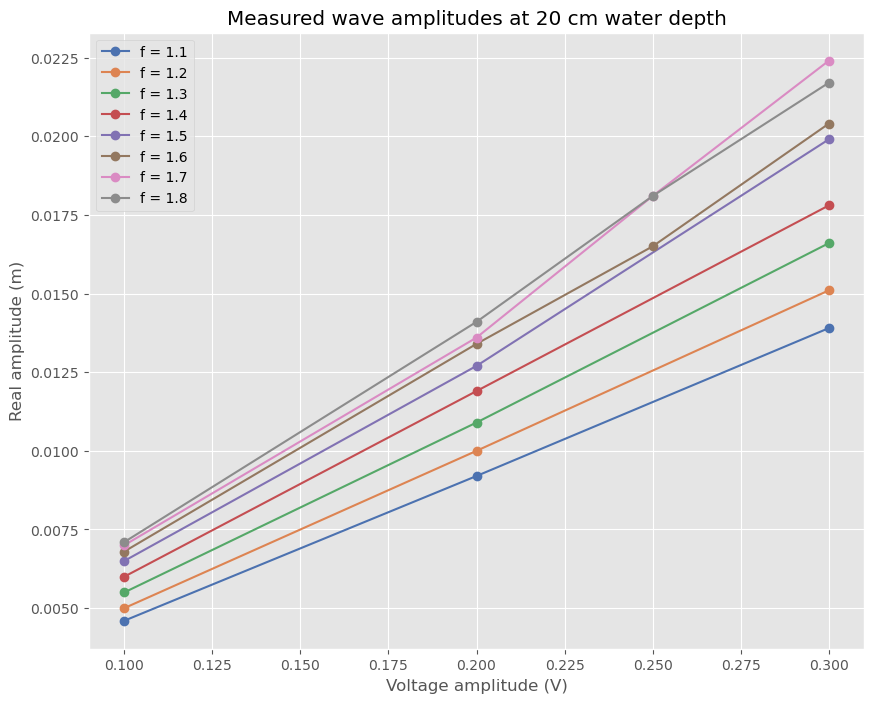

In [23]:
palette = sns.color_palette("deep", 8)

fig, ax = plt.subplots(figsize=(10,8))
ax.plot(f11_volt_amps_20, f11_real_amps_20, 'o-', color=palette[0], label='f = 1.1')
ax.plot(f12_volt_amps_20, f12_real_amps_20, 'o-', color=palette[1], label='f = 1.2')
ax.plot(f13_volt_amps_20, f13_real_amps_20, 'o-', color=palette[2], label='f = 1.3')
ax.plot(f14_volt_amps_20, f14_real_amps_20, 'o-', color=palette[3], label='f = 1.4')
ax.plot(f15_volt_amps_20, f15_real_amps_20, 'o-', color=palette[4], label='f = 1.5')
ax.plot(f16_volt_amps_20, f16_real_amps_20, 'o-', color=palette[5], label='f = 1.6')
ax.plot(f17_volt_amps_20, f17_real_amps_20, 'o-', color=palette[6], label='f = 1.7')
ax.plot(f18_volt_amps_20, f18_real_amps_20, 'o-', color=palette[7], label='f = 1.8')
ax.legend()
ax.set_xlabel('Voltage amplitude (V)')
ax.set_ylabel('Real amplitude (m)')

ax.set_title('Measured wave amplitudes at 20 cm water depth')

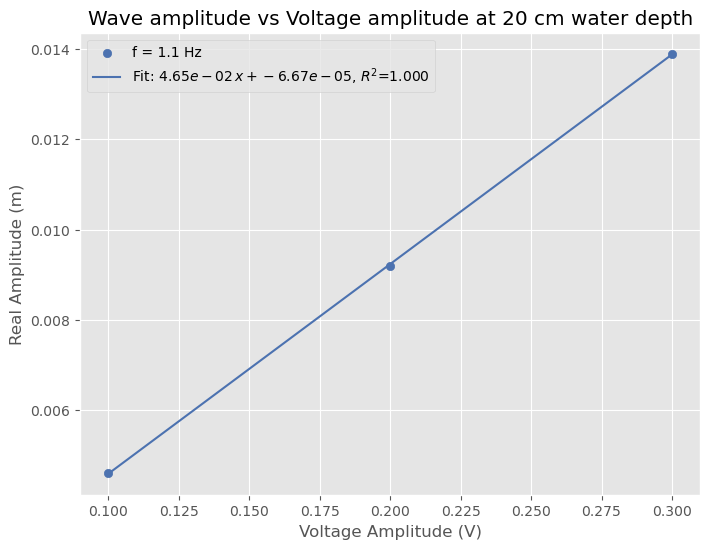

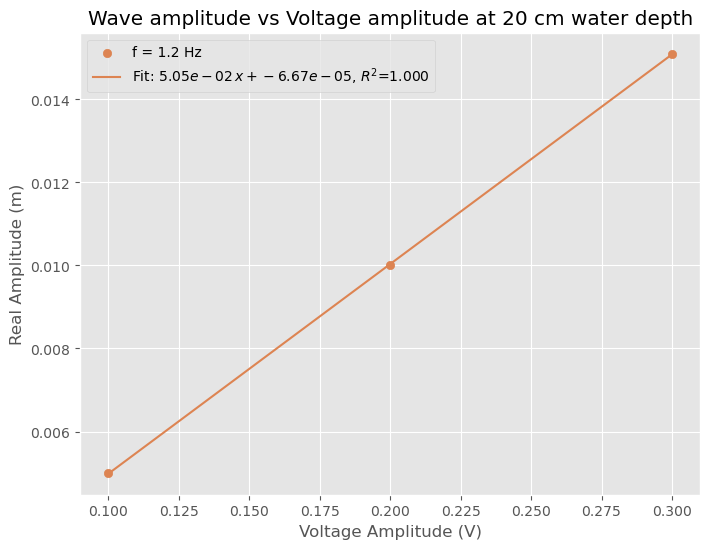

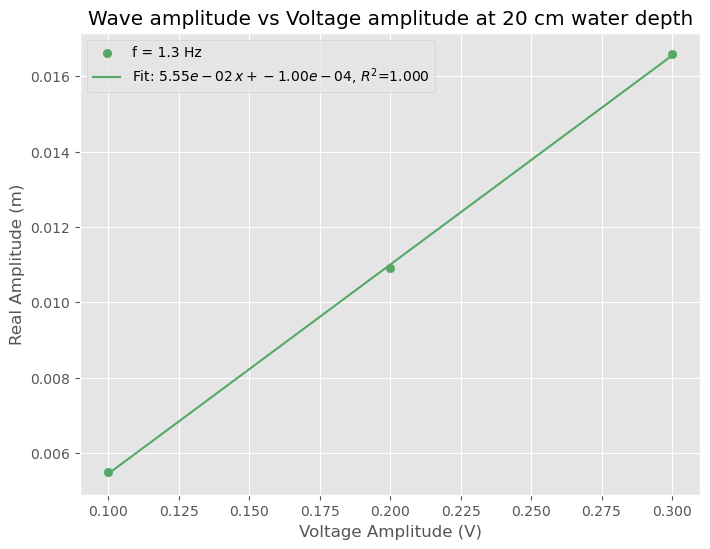

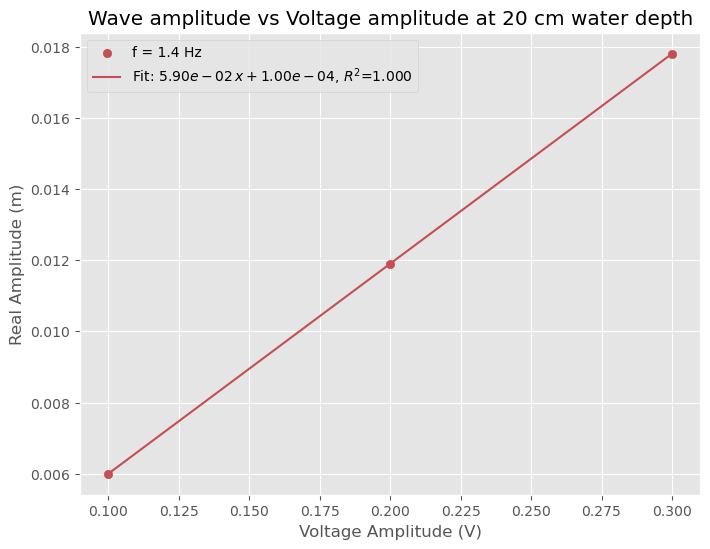

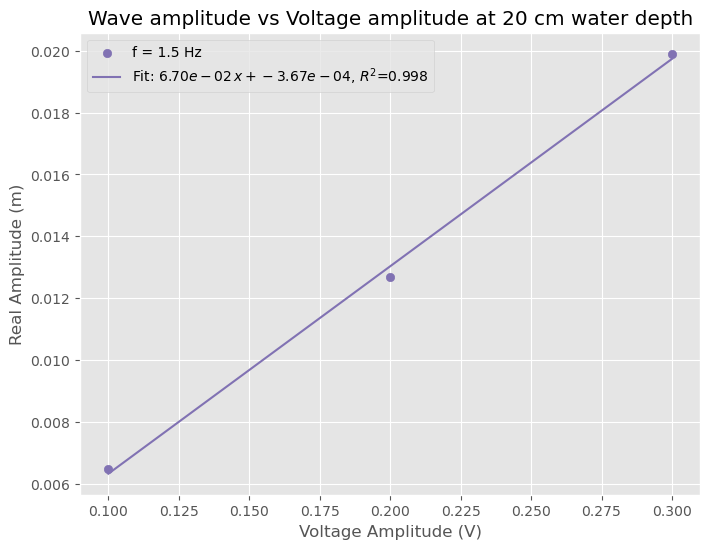

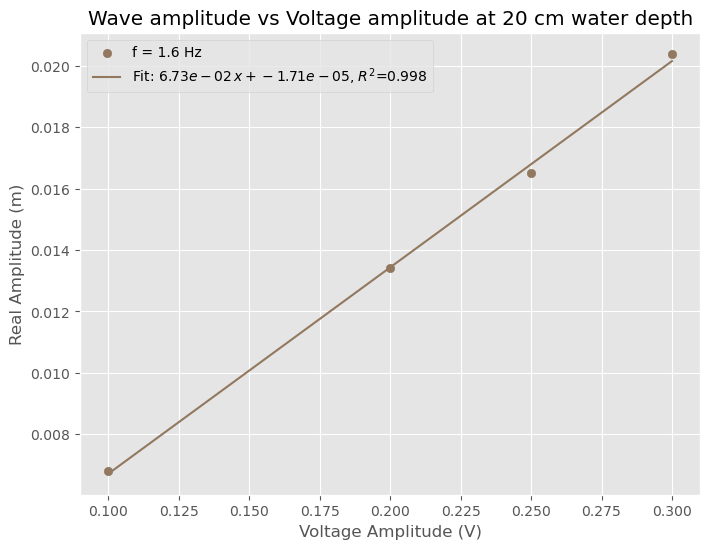

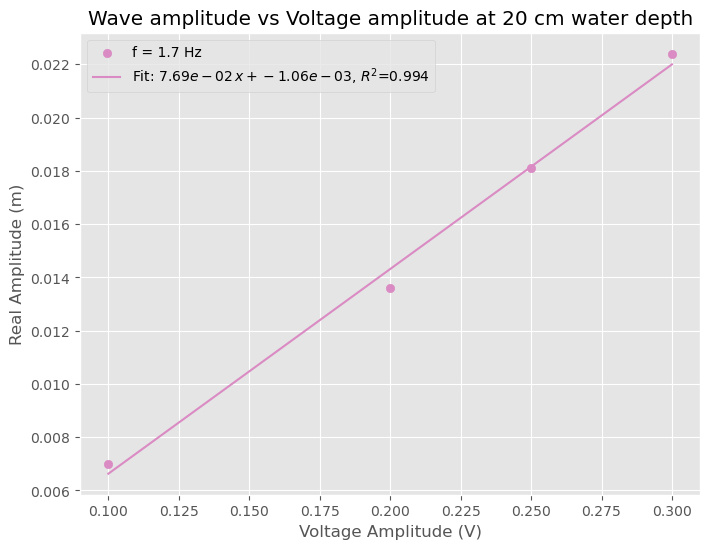

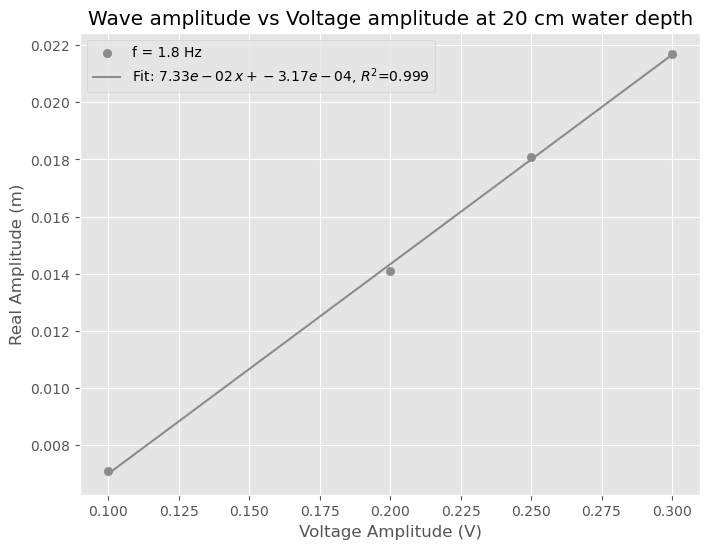

In [24]:
# Linear regression of real amplitude vs volt amplitude

volt_list = [f11_volt_amps_20, f12_volt_amps_20, f13_volt_amps_20,
             f14_volt_amps_20, f15_volt_amps_20, f16_volt_amps_20,
             f17_volt_amps_20, f18_volt_amps_20]

real_list = [f11_real_amps_20, f12_real_amps_20, f13_real_amps_20,
             f14_real_amps_20, f15_real_amps_20, f16_real_amps_20,
             f17_real_amps_20, f18_real_amps_20]

freqs = [1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8]

palette = sns.color_palette("deep", len(freqs))

results = []

for idx, (volt, real, freq) in enumerate(zip(volt_list, real_list, freqs)):
    volt = np.asarray(volt, dtype=float)
    real = np.asarray(real, dtype=float)

    # Fit linear model real = slope * volt + intercept
    coeff = np.polyfit(volt, real, 1)
    slope, intercept = float(coeff[0]), float(coeff[1])

    line = np.poly1d(coeff)
    r2 = r2_score(real, line(volt)) 

    results.append({
        "frequency": float(freq),
        "a_20": real,
        "V_20": volt,
        "slope": slope,
        "intercept": intercept,
        "r2": float(r2)
    })

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(volt, real, color=palette[idx], label=f'f = {freq} Hz')
    xx = np.linspace(volt.min(), volt.max(), 200)
    ax.plot(xx, line(xx), color=palette[idx],
            label=rf'Fit: ${slope:.2e}\,x + {intercept:.2e}$, $R^2$={r2:.3f}')
    ax.set_xlabel('Voltage Amplitude (V)')
    ax.set_ylabel('Real Amplitude (m)')
    ax.set_title('Wave amplitude vs Voltage amplitude at 20 cm water depth')
    ax.legend()
    plt.show()

# Create DataFrame
df_20 = pd.DataFrame(results, columns=["frequency", "a_20", "V_20", "slope", "intercept", "r2"])

The real amplitude to volt amplitude scale almost linearily. It should be noted that the data for the highest frequencies (1.5-1.8 Hz) and largest amplitudes (0.2-0.3 V) contain some outliers, still after corrections. Thus, the non-lineariy above could be due to that. I therefore assume a linear relation for all. Meaning a relation on the form:

$a_{1}(V) = k_{1}*V + b_{1}$

Where $a_{1}$ is the real amplitude in meters, $V$ amount of volt, $k$ is the slope and $b$ the intercept.


We have from above that, $a_{2} = a_{1}\frac{0.3}{0.2} = a_{1}*1.5$.

Which yields, $a_{2} = 1.5 * a_{1} = 1.5 * (k_{1}*V + b_{1})$. Thus, the voltage setting for the scaled amplitude at 30 cm water depth is, 

$V^* = \frac{a_{2} - 1.5*b_{1}}{1.5 * k_{1}}$.

In [25]:
df_20

,frequency,a_20,V_20,slope,intercept,r2
0,1.1,"[0.0046, 0.0092, 0.0139]","[0.1, 0.2, 0.3]",0.046500,-0.000067,0.999961
1,1.2,"[0.005, 0.01, 0.0151]","[0.1, 0.2, 0.3]",0.050500,-0.000067,0.999967
2,1.3,"[0.0055, 0.0109, 0.0166]","[0.1, 0.2, 0.3]",0.055500,-0.000100,0.999757
3,1.4,"[0.006, 0.0119, 0.0178]","[0.1, 0.2, 0.3]",0.059000,0.000100,1.000000
4,1.5,"[0.0065, 0.0127, 0.0199]","[0.1, 0.2, 0.3]",0.067000,-0.000367,0.998147
5,1.6,"[0.0068, 0.0134, 0.0165, 0.0204]","[0.1, 0.2, 0.25, 0.3]",0.067257,-0.000017,0.998432
6,1.7,"[0.007, 0.0136, 0.0181, 0.0224]","[0.1, 0.2, 0.25, 0.3]",0.076857,-0.001057,0.993760
7,1.8,"[0.0071, 0.0141, 0.0181, 0.0217]","[0.1, 0.2, 0.25, 0.3]",0.073257,-0.000317,0.999358


In [26]:
# Scaled frequencies from 20 cm to 30 cm water depth
scaled_freqs = []

for f in freqs:
    w_20 = 2 * np.pi * f
    w_30 = w_20 * np.sqrt(0.2 / 0.3)
    f_30 = w_30 / (2 * np.pi)
    scaled_freqs.append(f_30)

# Target real amplitudes (scaled from 20 cm) at 30 cm water depth
# Indicing frequencies
f0_real_amps_30 = f11_real_amps_20 * (0.3 / 0.2)
f1_real_amps_30 = f12_real_amps_20 * (0.3 / 0.2)
f2_real_amps_30 = f13_real_amps_20 * (0.3 / 0.2)
f3_real_amps_30 = f14_real_amps_20 * (0.3 / 0.2)
f4_real_amps_30 = f15_real_amps_20 * (0.3 / 0.2)
f5_real_amps_30 = f16_real_amps_20 * (0.3 / 0.2)
f6_real_amps_30 = f17_real_amps_20 * (0.3 / 0.2)
f7_real_amps_30 = f18_real_amps_20 * (0.3 / 0.2)

# Finding the corresponding volt amplitudes at 30 cm depth using the linear fits
f0_volt_amps_30 = (f0_real_amps_30 - (1.5 * df_20["intercept"].iloc[0])) / (1.5 * df_20["slope"].iloc[0])
f1_volt_amps_30 = (f1_real_amps_30 - (1.5 * df_20["intercept"].iloc[1])) / (1.5 * df_20["slope"].iloc[1])
f2_volt_amps_30 = (f2_real_amps_30 - (1.5 * df_20["intercept"].iloc[2])) / (1.5 * df_20["slope"].iloc[2])
f3_volt_amps_30 = (f3_real_amps_30 - (1.5 * df_20["intercept"].iloc[3])) / (1.5 * df_20["slope"].iloc[3])
f4_volt_amps_30 = (f4_real_amps_30 - (1.5 * df_20["intercept"].iloc[4])) / (1.5 * df_20["slope"].iloc[4])
f5_volt_amps_30 = (f5_real_amps_30 - (1.5 * df_20["intercept"].iloc[5])) / (1.5 * df_20["slope"].iloc[5])
f6_volt_amps_30 = (f6_real_amps_30 - (1.5 * df_20["intercept"].iloc[6])) / (1.5 * df_20["slope"].iloc[6])
f7_volt_amps_30 = (f7_real_amps_30 - (1.5 * df_20["intercept"].iloc[7])) / (1.5 * df_20["slope"].iloc[7])

volt_list = [f0_volt_amps_30, f1_volt_amps_30, f2_volt_amps_30,
             f3_volt_amps_30, f4_volt_amps_30, f5_volt_amps_30,
             f6_volt_amps_30, f7_volt_amps_30]

real_list = [f0_real_amps_30, f1_real_amps_30, f2_real_amps_30,
             f3_real_amps_30, f4_real_amps_30, f5_real_amps_30,
             f6_real_amps_30, f7_real_amps_30]

rows = []
for f_scaled, a30, v30 in zip(scaled_freqs, real_list, volt_list):
    f_scaled = np.round(f_scaled, 3)
    a30 = np.round(np.asarray(a30, dtype=float), 3)
    v30 = np.round(np.asarray(v30, dtype=float), 3)
    rows.append({
        "frequency": float(f_scaled),
        "a_30": a30,
        "V_30": v30
    })

df_30 = pd.DataFrame(rows, columns=["frequency", "a_30", "V_30"])


In [27]:
df_20

,frequency,a_20,V_20,slope,intercept,r2
0,1.1,"[0.0046, 0.0092, 0.0139]","[0.1, 0.2, 0.3]",0.046500,-0.000067,0.999961
1,1.2,"[0.005, 0.01, 0.0151]","[0.1, 0.2, 0.3]",0.050500,-0.000067,0.999967
2,1.3,"[0.0055, 0.0109, 0.0166]","[0.1, 0.2, 0.3]",0.055500,-0.000100,0.999757
3,1.4,"[0.006, 0.0119, 0.0178]","[0.1, 0.2, 0.3]",0.059000,0.000100,1.000000
4,1.5,"[0.0065, 0.0127, 0.0199]","[0.1, 0.2, 0.3]",0.067000,-0.000367,0.998147
5,1.6,"[0.0068, 0.0134, 0.0165, 0.0204]","[0.1, 0.2, 0.25, 0.3]",0.067257,-0.000017,0.998432
6,1.7,"[0.007, 0.0136, 0.0181, 0.0224]","[0.1, 0.2, 0.25, 0.3]",0.076857,-0.001057,0.993760
7,1.8,"[0.0071, 0.0141, 0.0181, 0.0217]","[0.1, 0.2, 0.25, 0.3]",0.073257,-0.000317,0.999358


In [28]:
df_30

,frequency,a_30,V_30
0,0.898,"[0.007, 0.014, 0.021]","[0.1, 0.199, 0.3]"
1,0.980,"[0.007, 0.015, 0.023]","[0.1, 0.199, 0.3]"
2,1.061,"[0.008, 0.016, 0.025]","[0.101, 0.198, 0.301]"
3,1.143,"[0.009, 0.018, 0.027]","[0.1, 0.2, 0.3]"
4,1.225,"[0.01, 0.019, 0.03]","[0.102, 0.195, 0.302]"
5,1.306,"[0.01, 0.02, 0.025, 0.031]","[0.101, 0.199, 0.246, 0.304]"
6,1.388,"[0.01, 0.02, 0.027, 0.034]","[0.105, 0.191, 0.249, 0.305]"
7,1.470,"[0.011, 0.021, 0.027, 0.033]","[0.101, 0.197, 0.251, 0.301]"


The first attempt at scaling from 20 cm to 30 cm above, failed. The 1st, 4th and 8th frequency were run on 30 cm, for all respective amplitudes. kH was preserved in all cases, but ak was not. The observed amplitude was identical at 30 cm to the corresponding waves at 20 cm. The wish was for the amplitude to be scaled by a factor of 1.5. Therefore I take a new approach, and directly scale the amplitude in volts with 1.5.

In [30]:
# Scaled frequencies from 20 cm to 30 cm water depth
scaled_freqs = []

for f in freqs:
    w_20 = 2 * np.pi * f
    w_30 = w_20 * np.sqrt(0.2 / 0.3)
    f_30 = w_30 / (2 * np.pi)
    scaled_freqs.append(f_30)

# Target real amplitudes (scaled from 20 cm) at 30 cm water depth
# Indicing frequencies
f0_real_amps_30 = f11_real_amps_20 * (0.3 / 0.2)
f1_real_amps_30 = f12_real_amps_20 * (0.3 / 0.2)
f2_real_amps_30 = f13_real_amps_20 * (0.3 / 0.2)
f3_real_amps_30 = f14_real_amps_20 * (0.3 / 0.2)
f4_real_amps_30 = f15_real_amps_20 * (0.3 / 0.2)
f5_real_amps_30 = f16_real_amps_20 * (0.3 / 0.2)
f6_real_amps_30 = f17_real_amps_20 * (0.3 / 0.2)
f7_real_amps_30 = f18_real_amps_20 * (0.3 / 0.2)

# NEW APPROACH
# Finding the corresponding volt amplitudes at 30 cm depth by directly scaling the 20 cm volt amplitudes
f0_volt_amps_30 = np.array([0.1, 0.2, 0.3]) * 1.5
f1_volt_amps_30 = np.array([0.1, 0.2, 0.3]) * 1.5
f2_volt_amps_30 = np.array([0.1, 0.2, 0.3]) * 1.5
f3_volt_amps_30 = np.array([0.1, 0.2, 0.3]) * 1.5
f4_volt_amps_30 = np.array([0.1, 0.2, 0.3]) * 1.5
f5_volt_amps_30 = np.array([0.1, 0.2, 0.25, 0.3]) * 1.5
f6_volt_amps_30 = np.array([0.1, 0.2, 0.25, 0.3]) * 1.5
f7_volt_amps_30 = np.array([0.1, 0.2, 0.25, 0.3]) * 1.5

volt_list = [f0_volt_amps_30, f1_volt_amps_30, f2_volt_amps_30,
             f3_volt_amps_30, f4_volt_amps_30, f5_volt_amps_30,
             f6_volt_amps_30, f7_volt_amps_30]

real_list = [f0_real_amps_30, f1_real_amps_30, f2_real_amps_30,
             f3_real_amps_30, f4_real_amps_30, f5_real_amps_30,
             f6_real_amps_30, f7_real_amps_30]

rows = []
for f_scaled, a30, v30 in zip(scaled_freqs, real_list, volt_list):
    f_scaled = np.round(f_scaled, 3)
    a30 = np.round(np.asarray(a30, dtype=float), 3)
    v30 = np.round(np.asarray(v30, dtype=float), 3)
    rows.append({
        "frequency": float(f_scaled),
        "a_30": a30,
        "V_30": v30
    })

df_30_new = pd.DataFrame(rows, columns=["frequency", "a_30", "V_30"])


In [31]:
df_30_new

,frequency,a_30,V_30
0,0.898,"[0.007, 0.014, 0.021]","[0.15, 0.3, 0.45]"
1,0.980,"[0.007, 0.015, 0.023]","[0.15, 0.3, 0.45]"
2,1.061,"[0.008, 0.016, 0.025]","[0.15, 0.3, 0.45]"
3,1.143,"[0.009, 0.018, 0.027]","[0.15, 0.3, 0.45]"
4,1.225,"[0.01, 0.019, 0.03]","[0.15, 0.3, 0.45]"
5,1.306,"[0.01, 0.02, 0.025, 0.031]","[0.15, 0.3, 0.375, 0.45]"
6,1.388,"[0.01, 0.02, 0.027, 0.034]","[0.15, 0.3, 0.375, 0.45]"
7,1.470,"[0.011, 0.021, 0.027, 0.033]","[0.15, 0.3, 0.375, 0.45]"
